In [ ]:
import numpy as np
from scipy.optimize import least_squares

def power_model(gamma_g, Pg, gamma_s, S):
    """
    Modelo de potencia del método de Furrer/Hall.

    S = [S11, S12, S21, S22]
    """

    S11, S12, S21, S22 = S

    numerator = (
        Pg
        * (1 - abs(gamma_s)**2)
        * abs(S21)**2
    )

    denominator = abs(
        (1 - S11 * gamma_g)
        * (1 - S22 * gamma_s)
        - S12 * S21 * gamma_g * gamma_s
    )**2

    return numerator / denominator


def fit_gamma(P_meas, uP, Pg, gamma_s, S_all):
    """
    Ajusta Re(Gamma_g) e Im(Gamma_g).

    P_meas : array [N] en W
    uP     : incertidumbre estándar de cada P_i en W
    Pg     : potencia disponible del generador en W
    gamma_s: coeficiente complejo del sensor
    S_all  : array [N,4] complejo
             columnas: S11, S12, S21, S22
    """

    def residual(x):

        gamma_g = x[0] + 1j * x[1]

        P_model = np.array([power_model(gamma_g, Pg, gamma_s, S) for S in S_all])

        return (P_model - P_meas) / uP

    # Valor inicial
    x0 = np.array([0.0, 0.0])

    bounds = (
        [-0.99, -0.99],
        [ 0.99,  0.99]
    )

    result = least_squares(residual, x0, bounds=bounds)

    gamma_g = result.x[0] + 1j * result.x[1]

    return gamma_g, result

In [ ]:

gamma, result = fit_gamma(P_meas=P, uP=uP, Pg=Pg, gamma_s=gamma_sensor, S_all=S )

print("Gamma =", gamma)
print("Mag   =", abs(gamma))
print("Phase =", np.angle(gamma, deg=True))

swr = (1 + abs(gamma)) / (1 - abs(gamma))
rl = -20 * np.log10(abs(gamma))

print("VSWR  =", swr)
print("RL    =", rl, "dB")

## Teoria

Estimacion del coeficiente de reflexion de la fuente (Gamma_s, "source match") de un generador de senales, con el setup de acoplador direccional + linea de transmision (carga deslizante / offset loads), siguiendo el metodo de Furrer/de Vreede con trazabilidad metrologica (Juroshek, NPL):

https://www.researchgate.net/publication/333078487_Measuring_Signal_Generator_Source_Match

METODO DE MEDICION
-------------------

El generador alimenta un acoplador direccional; en el brazo acoplado se mide
potencia escalar (medidor de potencia / analizador de espectro). Sobre la
linea de transmision, aguas abajo del acoplador, se conecta una carga cuyo
Gamma_L (magnitud y fase) se varia (deslizandola, o insertando tramos de
linea de distinta longitud) y se caracteriza previamente en el VNA. Para cada
posicion/carga i se mide la potencia P_i.


Modelo (onda emergente del generador hacia el acoplador, con Gamma_s desconocido, que se re-refleja contra cada carga):


    a(Gamma_L) = a0 / (1 - Gamma_s * Gamma_L)


- Si el acoplador muestrea la onda que viaja HACIA la carga:
      P_i = P0 / |1 - Gamma_s * Gamma_L,i|^2                    ('incident')
- Si muestrea la onda REFLEJADA por la carga (b = Gamma_L * a):
      P_i = P0 * |Gamma_L,i|^2 / |1 - Gamma_s * Gamma_L,i|^2    ('reflected')


Incognitas: Gamma_s = x + j*y (2 reales) y P0 (1 real) -> minimo 3 cargas de
fase distinta; se recomiendan >=5-6 para tener redundancia.


INCERTIDUMBRE:
-------------------------------------------------------------------------

LEY DE PROPAGACION BIVARIANTE (Ridler & Salter, Metrologia 39, 2002)


El resultado theta_hat = (Re(Gamma_s), Im(Gamma_s), P0) no es una funcion cerrada de las entradas: es la solucion de un ajuste no lineal. El GUM (seccion 5.1.4 / Supplement 2) indica que cuando el "modelo" es un algoritmo/procedimiento, los coeficientes de sensibilidad c_k = d(theta)/d(u_k) se obtienen evaluando como cambia el resultado ante variaciones de cada entrada -- aqui se obtienen por diferenciacion implicita de la condicion de optimo del ajuste (aproximacion de Gauss-Newton, la misma que usa cualquier software de regresion no lineal para el error estandar de los parametros, aqui generalizada a "errors-in-variables" porque Gamma_L,i tambien es incierto):


    En el optimo:            J_theta^T @ r(theta, u) = 0
    Derivando respecto a u:  J_theta^T @ (J_theta @ dtheta + J_u @ du) = 0    =>  d(theta)/d(u) = S = -(J_theta^T J_theta)^-1 J_theta^T J_u


donde J_theta = d(residuos)/d(theta) (Jacobiano del ajuste, en el optimo) y J_u = d(residuos)/d(entradas) (sensibilidad del modelo a cada Gamma_L,i y cada P_i medidos). Luego:


    Cov(theta_hat) = S @ Cov(u) @ S^T


Esto es exactamente la "ley de propagacion" (LPU) generalizada de forma
bivariante: una matriz de covarianza real 2x2 (o 3x3 con P0) en lugar de una
varianza escalar, tal como formulan Ridler & Salter para S-parametros
complejos.

## Datos/Funciones Auxiliares

In [ ]:
import numpy as np
from scipy.optimize import least_squares
from scipy.stats import chi2, t as student_t
import matplotlib.pyplot as plt


# 'incident'  -> el acoplador muestrea la onda que va hacia la carga
# 'reflected' -> el acoplador muestrea la onda reflejada por la carga
WAVE_DIRECTION = 'incident'

# Cada carga / posicion de la linea deslizante:
# (|Gamma_L|, fase_L en grados, u(|Gamma_L|) 1-sigma, u(fase_L) en grados 1-sigma)
# Estos valores y sus incertidumbres salen de la caracterizacion en el VNA
# (residuales de calibracion: directividad, match del puerto, tracking, etc.)
loads = [
    (0.20, 0,    0.01, 3),
    (0.20, 60,   0.01, 3),
    (0.20, 120,  0.01, 3),
    (0.20, 180,  0.01, 3),
    (0.20, 240,  0.01, 3),
    (0.20, 300,  0.01, 3),
    (0.02, 0,    0.01, 10),   # carga de referencia ~50 ohm (opcional)
]

# Potencia medida con el generador para cada carga, en dBm, mismo orden que
# 'loads', con su incertidumbre estandar (1-sigma) en dB (ruido del medidor,
# resolucion, repetibilidad, linealidad, etc.)
power_dBm  = np.array([9.85, 10.20, 9.65, 9.80, 10.15, 9.95, 10.00])
u_power_dB = np.array([0.05, 0.05,  0.05, 0.05, 0.05,  0.05, 0.05])

CONFIDENCE = 0.95   # nivel de confianza para la incertidumbre expandida

def dBm_to_W(p_dbm):
    return 10 ** (np.asarray(p_dbm) / 10.0) / 1000.0

def gamma_complex(mag, phase_deg):
    return mag * np.exp(1j * np.deg2rad(phase_deg))


## Estimación de Valor

In [6]:
def model_power(x, y, P0, a, b, direction=WAVE_DIRECTION):
    """Potencia predicha (W) para Gamma_s=x+jy, carga Gamma_L=a+jb."""
    Dr = 1 - (x * a - y * b)       # Re(1 - Gs*GL)
    Di = -(x * b + y * a)          # Im(1 - Gs*GL)
    den = Dr ** 2 + Di ** 2
    if direction == 'incident':
        return P0 / den
    elif direction == 'reflected':
        return P0 * (a ** 2 + b ** 2) / den
    else:
        raise ValueError("direction debe ser 'incident' o 'reflected'")


def residuals_weighted(params, a, b, P_meas, sigma_P, direction):
    x, y, P0 = params
    P_model = model_power(x, y, P0, a, b, direction)
    return (P_model - P_meas) / sigma_P


def fit_gamma_s(a, b, P_meas, sigma_P, x0, direction=WAVE_DIRECTION):
    res = least_squares(
        residuals_weighted, x0, args=(a, b, P_meas, sigma_P, direction),
        bounds=([-0.999, -0.999, 1e-12], [0.999, 0.999, np.inf]),
        method='trf', xtol=1e-14, ftol=1e-14, gtol=1e-14
    )
    x, y, P0 = res.x
    return x + 1j * y, P0, res


In [7]:
mags   = np.array([l[0] for l in loads])
phases = np.array([l[1] for l in loads])
u_mag  = np.array([l[2] for l in loads])
u_ph_deg = np.array([l[3] for l in loads])
u_ph   = np.deg2rad(u_ph_deg)

a_nom = mags * np.cos(np.deg2rad(phases))   # Re(Gamma_L,i)
b_nom = mags * np.sin(np.deg2rad(phases))   # Im(Gamma_L,i)

P_nom = dBm_to_W(power_dBm)
# Incertidumbre de potencia: dB -> lineal (propagacion estandar log->lineal)
sigma_P = P_nom * np.log(10) / 10 * u_power_dB

N = len(loads)
if N < 3:
    raise ValueError("Se necesitan al menos 3 cargas de fase distinta.")

x0 = (0.0, 0.0, np.mean(P_nom))
Gs_hat, P0_hat, fitres = fit_gamma_s(a_nom, b_nom, P_nom, sigma_P, x0)

if not fitres.success:
    print("AVISO: el ajuste no convergio correctamente:", fitres.message)

theta_hat = np.array([Gs_hat.real, Gs_hat.imag, P0_hat])

print("=" * 62)
print("RESULTADO CENTRAL (minimos cuadrados no lineales ponderados)")
print("=" * 62)
print(f"Gamma_s = {Gs_hat.real:+.4f} {Gs_hat.imag:+.4f}j")
print(f"  |Gamma_s|   = {abs(Gs_hat):.4f}")
print(f"  fase        = {np.angle(Gs_hat, deg=True):+.2f} deg")
print(f"  Return loss = {-20*np.log10(abs(Gs_hat)):.2f} dB")
print(f"P0 estimado = {P0_hat*1000:.4f} mW ({10*np.log10(P0_hat*1000):.3f} dBm equiv.)")
chi2_red = 2 * fitres.cost / max(N - 3, 1)
print(f"Chi-cuadrado reducido = {chi2_red:.3f}  "
      f"(~1 indica residuos consistentes con las incertidumbres declaradas)")

RESULTADO CENTRAL (minimos cuadrados no lineales ponderados)
Gamma_s = +0.0405 +0.0456j
  |Gamma_s|   = 0.0610
  fase        = +48.42 deg
  Return loss = 24.29 dB
P0 estimado = 9.8456 mW (9.932 dBm equiv.)
Chi-cuadrado reducido = 19.037  (~1 indica residuos consistentes con las incertidumbres declaradas)


## Incertidumbre

In [8]:
# --- 4.1 Covarianza de las entradas Cov(u) --------------------------------
# Vector de entradas u = [Re(GL_1),Im(GL_1),P_1, Re(GL_2),Im(GL_2),P_2, ...]
# Bloques 3x3 independientes entre cargas (se asume que la caracterizacion
# de cada carga y cada medicion de potencia son independientes entre si).

Cov_u = np.zeros((3 * N, 3 * N))
for i in range(N):
    m, phi = mags[i], np.deg2rad(phases[i])
    um, uphi = u_mag[i], u_ph[i]
    # Jacobiano polar -> cartesiano para la carga i
    J_polar = np.array([
        [np.cos(phi), -m * np.sin(phi)],
        [np.sin(phi),  m * np.cos(phi)],
    ])
    Cov_polar = np.diag([um ** 2, uphi ** 2])
    Cov_ReIm = J_polar @ Cov_polar @ J_polar.T   # 2x2: Re/Im de Gamma_L,i

    blk = np.zeros((3, 3))
    blk[0:2, 0:2] = Cov_ReIm
    blk[2, 2] = sigma_P[i] ** 2
    Cov_u[3*i:3*i+3, 3*i:3*i+3] = blk

# --- 4.2 Jacobiano del ajuste respecto a theta (en el optimo) -------------
# scipy ya lo computa numericamente al converger (metodo TRF).
J_theta = fitres.jac   # (N, 3), d(residuo_i)/d(theta_j)

# --- 4.3 Jacobiano del residuo respecto a las entradas u -------------------
# (derivadas parciales numericas del residuo i respecto a Re(GL_i), Im(GL_i)
#  y P_i, manteniendo theta fijo en el optimo; el residuo i solo depende de
#  la entrada i -> bloques 1x3, matriz (N, 3N))

def residual_i(i, a_i, b_i, P_i, theta):
    x, y, P0 = theta
    Pm = model_power(x, y, P0, a_i, b_i, WAVE_DIRECTION)
    return (Pm - P_i) / sigma_P[i]

J_u = np.zeros((N, 3 * N))
h_rel = 1e-6
for i in range(N):
    a_i, b_i, P_i = a_nom[i], b_nom[i], P_nom[i]

    ha = max(abs(a_i), 1e-3) * h_rel
    J_u[i, 3*i+0] = (residual_i(i, a_i+ha, b_i, P_i, theta_hat)
                      - residual_i(i, a_i-ha, b_i, P_i, theta_hat)) / (2*ha)

    hb = max(abs(b_i), 1e-3) * h_rel
    J_u[i, 3*i+1] = (residual_i(i, a_i, b_i+hb, P_i, theta_hat)
                      - residual_i(i, a_i, b_i-hb, P_i, theta_hat)) / (2*hb)

    # d(residuo_i)/dP_i es analitico y exacto: -1/sigma_P_i
    J_u[i, 3*i+2] = -1.0 / sigma_P[i]

# --- 4.4 Matriz de sensibilidad S = d(theta)/d(u) y covarianza de salida --
H = J_theta.T @ J_theta                      # Hessiano Gauss-Newton (3x3)
H_inv = np.linalg.inv(H)
S = -H_inv @ J_theta.T @ J_u                 # (3, 3N)  coeficientes de sensibilidad

Cov_theta = S @ Cov_u @ S.T                  # (3,3): [Re(Gs), Im(Gs), P0]

Cov_Gs = Cov_theta[0:2, 0:2]
u_re = np.sqrt(Cov_Gs[0, 0])
u_im = np.sqrt(Cov_Gs[1, 1])
rho_ReIm = Cov_Gs[0, 1] / (u_re * u_im)
u_P0 = np.sqrt(Cov_theta[2, 2])

print("\n" + "=" * 62)
print("INCERTIDUMBRE (ley de propagacion bivariante, k=1 / 1 sigma)")
print("=" * 62)
print(f"u(Re(Gamma_s)) = {u_re:.4f}")
print(f"u(Im(Gamma_s)) = {u_im:.4f}")
print(f"correlacion Re-Im = {rho_ReIm:+.3f}")
print(f"u(P0) = {u_P0*1000:.4f} mW")

# --- 4.5 Incertidumbre expandida por componente (comparable a las barras
#         de error del paper, Fig. 2 y 3: Re e Im por separado) -----------
dof = max(N - 3, 1)
k_expand = student_t.ppf(1 - (1 - CONFIDENCE) / 2, dof) if dof < 30 else 1.96
U_re = k_expand * u_re
U_im = k_expand * u_im

print(f"\nIncertidumbre expandida por componente (k={k_expand:.3f}, "
      f"{CONFIDENCE*100:.0f}% conf., {dof} g.l.):")
print(f"  Re(Gamma_s) = {Gs_hat.real:+.4f} +/- {U_re:.4f}")
print(f"  Im(Gamma_s) = {Gs_hat.imag:+.4f} +/- {U_im:.4f}")

# --- 4.6 Region de incertidumbre conjunta (elipse, distribucion normal
#         bivariante con 2 grados de libertad) -----------------------------
k95_ellipse = np.sqrt(chi2.ppf(CONFIDENCE, df=2))
eigvals, eigvecs = np.linalg.eigh(Cov_Gs)
order = np.argsort(eigvals)[::-1]
eigvals, eigvecs = eigvals[order], eigvecs[:, order]
semi_axes = k95_ellipse * np.sqrt(eigvals)
angle_ellipse = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))

print(f"\nElipse de incertidumbre conjunta al {CONFIDENCE*100:.0f}% "
      f"(factor k={k95_ellipse:.3f}, chi2 con 2 g.l.):")
print(f"  semieje mayor = {semi_axes[0]:.4f}")
print(f"  semieje menor = {semi_axes[1]:.4f}")
print(f"  orientacion   = {angle_ellipse:.1f} deg respecto al eje Re(Gamma)")


INCERTIDUMBRE (ley de propagacion bivariante, k=1 / 1 sigma)
u(Re(Gamma_s)) = 0.0165
u(Im(Gamma_s)) = 0.0169
correlacion Re-Im = -0.048
u(P0) = 0.0431 mW

Incertidumbre expandida por componente (k=2.776, 95% conf., 4 g.l.):
  Re(Gamma_s) = +0.0405 +/- 0.0458
  Im(Gamma_s) = +0.0456 +/- 0.0470

Elipse de incertidumbre conjunta al 95% (factor k=2.448, chi2 con 2 g.l.):
  semieje mayor = 0.0420
  semieje menor = 0.0398
  orientacion   = 121.1 deg respecto al eje Re(Gamma)


## Gráfico


Grafico guardado en gamma_s_result.png


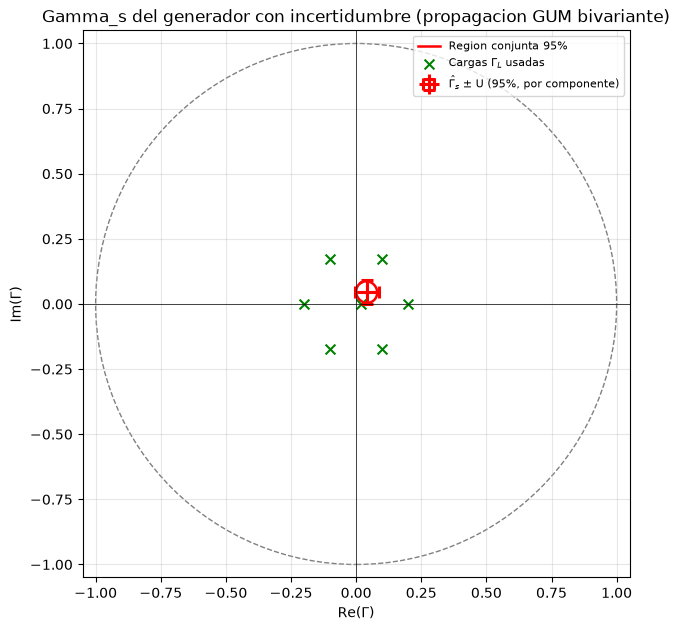

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))

ax.errorbar(Gs_hat.real, Gs_hat.imag, xerr=U_re, yerr=U_im,
            fmt='r+', markersize=14, mew=2.2, capsize=4,
            label=fr'$\hat{{\Gamma}}_s$ $\pm$ U ({CONFIDENCE*100:.0f}%, por componente)')

theta_grid = np.linspace(0, 2 * np.pi, 300)
ellipse = eigvecs @ np.diag(semi_axes) @ np.array([np.cos(theta_grid), np.sin(theta_grid)])
ax.plot(Gs_hat.real + ellipse[0], Gs_hat.imag + ellipse[1], 'r-', lw=1.8,
        label=f'Region conjunta {CONFIDENCE*100:.0f}%')

circle = plt.Circle((0, 0), 1, fill=False, linestyle='--', color='gray', lw=1)
ax.add_patch(circle)
ax.scatter(a_nom, b_nom, marker='x', color='green', s=50,
           label=r'Cargas $\Gamma_L$ usadas')

ax.axhline(0, color='black', lw=0.5)
ax.axvline(0, color='black', lw=0.5)
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_aspect('equal')
ax.set_xlabel(r'Re($\Gamma$)')
ax.set_ylabel(r'Im($\Gamma$)')
ax.set_title('Gamma_s del generador con incertidumbre (propagacion GUM bivariante)')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
print("\nGrafico guardado en gamma_s_result.png")
plt.show()